# LAB | Imbalanced

**Load the data**

In this challenge, we will be working with Credit Card Fraud dataset.

https://raw.githubusercontent.com/data-bootcamp-v4/data/main/card_transdata.csv

Metadata

- **distance_from_home:** the distance from home where the transaction happened.
- **distance_from_last_transaction:** the distance from last transaction happened.
- **ratio_to_median_purchase_price:** Ratio of purchased price transaction to median purchase price.
- **repeat_retailer:** Is the transaction happened from same retailer.
- **used_chip:** Is the transaction through chip (credit card).
- **used_pin_number:** Is the transaction happened by using PIN number.
- **online_order:** Is the transaction an online order.
- **fraud:** Is the transaction fraudulent. **0=legit** -  **1=fraud**


In [1]:
#Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
fraud = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/card_transdata.csv")
fraud.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


**Steps:**

- **1.** What is the distribution of our target variable? Can we say we're dealing with an imbalanced dataset?
- **2.** Train a LogisticRegression.
- **3.** Evaluate your model. Take in consideration class importance, and evaluate it by selection the correct metric.
- **4.** Run **Oversample** in order to balance our target variable and repeat the steps above, now with balanced data. Does it improve the performance of our model? 
- **5.** Now, run **Undersample** in order to balance our target variable and repeat the steps above (1-3), now with balanced data. Does it improve the performance of our model?
- **6.** Finally, run **SMOTE** in order to balance our target variable and repeat the steps above (1-3), now with balanced data. Does it improve the performance of our model? 

<Axes: xlabel='fraud'>

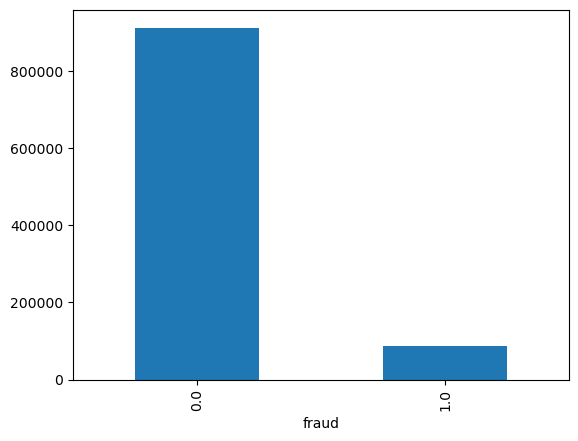

In [ ]:
#The distribution of the target "fraud" is very imbalanced

fraud["fraud"].value_counts().plot(kind="bar")

In [5]:
fraud.dtypes

distance_from_home                float64
distance_from_last_transaction    float64
ratio_to_median_purchase_price    float64
repeat_retailer                   float64
used_chip                         float64
used_pin_number                   float64
online_order                      float64
fraud                             float64
dtype: object

In [16]:
# Train Logistic Regression 

from sklearn.linear_model import LogisticRegression 

x = fraud.drop(columns = "fraud")
y = fraud["fraud"]


# train_test_split 
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0, stratify=target)


# Train the model 
log_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=0)
log_model.fit(X_train, y_train)

pred = log_model.predict(X_test)


In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

         0.0       0.99      0.93      0.96    182519
         1.0       0.57      0.95      0.71     17481

    accuracy                           0.93    200000
   macro avg       0.78      0.94      0.84    200000
weighted avg       0.96      0.93      0.94    200000



In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)
cm

array([[170098,  12421],
       [   873,  16608]])

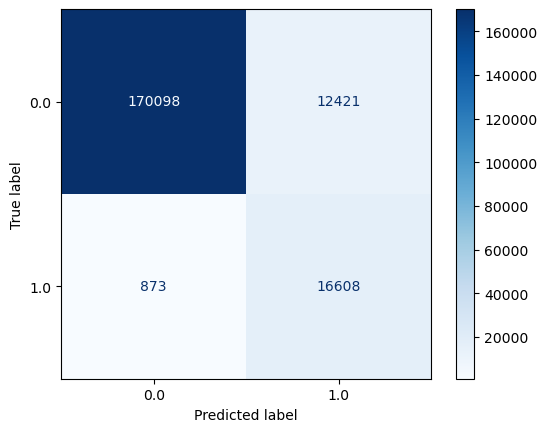

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, pred, cmap="Blues")

### OVERSAMPLE

In [20]:
fraud_positive = fraud[fraud["fraud"] == 1.0]
fraud_negative = fraud[fraud["fraud"] == 0.0]

In [32]:
from sklearn.utils import resample

fraud_positive_oversampled = resample(
    fraud_positive,
    replace=True,
    n_samples=len(fraud_negative),
    random_state=0
)

In [34]:
fraud_final = pd.concat([fraud_positive_oversampled, fraud_negative])
fraud_final.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
781436,17.156979,1.032954,17.862495,1.0,1.0,0.0,1.0,1.0
498904,70.424731,1.023682,9.211348,1.0,0.0,0.0,1.0,1.0
488212,10.629216,0.932118,4.317376,1.0,1.0,0.0,1.0,1.0
525384,3.316171,5.486249,36.540108,1.0,1.0,0.0,1.0,1.0
244343,209.444337,14.344290,4.585371,1.0,1.0,0.0,1.0,1.0


In [36]:
fraud_final["fraud"].value_counts()

fraud
1.0    912597
0.0    912597
Name: count, dtype: int64

In [38]:
x = fraud_final.drop(columns = "fraud")
y = fraud_final["fraud"]


# train_test_split 
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0, stratify=y)


# Train the model 
log_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=0)
log_model.fit(X_train, y_train)

pred = log_model.predict(X_test)

In [39]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

         0.0       0.95      0.93      0.94    182520
         1.0       0.93      0.95      0.94    182519

    accuracy                           0.94    365039
   macro avg       0.94      0.94      0.94    365039
weighted avg       0.94      0.94      0.94    365039



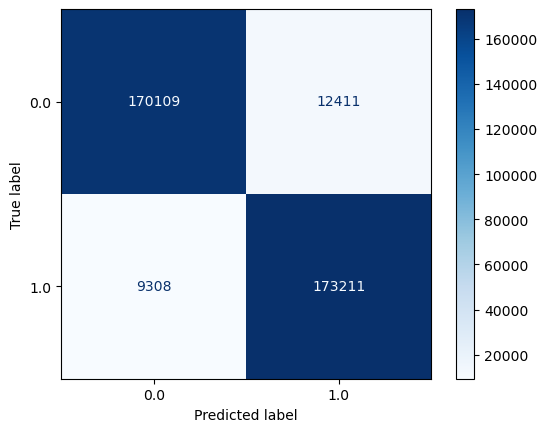

In [40]:

ConfusionMatrixDisplay.from_predictions(y_test, pred, cmap="Blues")

Oversampling gives sligtly higer accuracy but more misclassifications. 

### UNDERSAMPLING 

In [41]:
fraud_negative_oversampled = resample(
    fraud_negative,
    replace=False,
    n_samples=len(fraud_positive),
    random_state=0
)

In [43]:
fraud_final2 = pd.concat([fraud_negative_oversampled, fraud_positive])
fraud_final2.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
463944,9.454805,0.036985,3.224905,1.0,1.0,0.0,1.0,0.0
126410,2.194561,2.267504,0.064518,1.0,1.0,0.0,1.0,0.0
184900,28.035257,2.365139,0.182393,1.0,0.0,0.0,1.0,0.0
448245,16.426634,22.357581,0.724242,1.0,0.0,0.0,1.0,0.0
915523,25.267437,2.353905,0.599941,1.0,0.0,0.0,1.0,0.0


In [46]:
fraud_final2["fraud"].value_counts()

fraud
0.0    87403
1.0    87403
Name: count, dtype: int64

In [48]:
x = fraud_final2.drop(columns = "fraud")
y = fraud_final2["fraud"]


# train_test_split 
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0, stratify=y)


# Train the model 
log_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=0)
log_model.fit(X_train, y_train)

pred = log_model.predict(X_test)

In [50]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

         0.0       0.95      0.93      0.94     17481
         1.0       0.93      0.95      0.94     17481

    accuracy                           0.94     34962
   macro avg       0.94      0.94      0.94     34962
weighted avg       0.94      0.94      0.94     34962



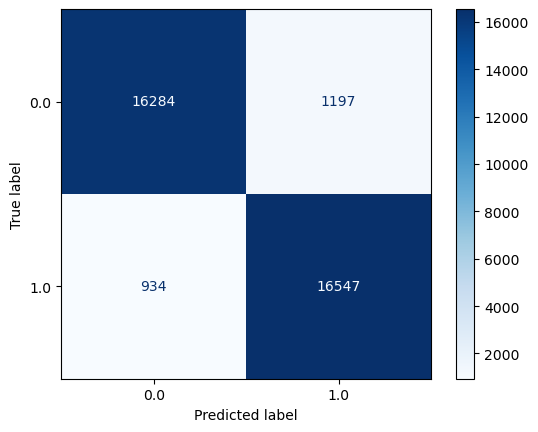

In [49]:
ConfusionMatrixDisplay.from_predictions(y_test, pred, cmap="Blues")

Undersampling also improves sligtly the accuracy but also gives more misclassification. 

### SMOTE

In [51]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=0)

X_smote, y_smote = smote.fit_resample(
    X_train,
    y_train
)

print(pd.Series(y_smote).value_counts())

fraud
1.0    69922
0.0    69922
Name: count, dtype: int64


In [52]:
smote_model = LogisticRegression(max_iter=1000)

smote_model.fit(X_smote, y_smote)

smote_pred = smote_model.predict(X_test)

In [56]:
print(classification_report(y_test, smote_pred))

              precision    recall  f1-score   support

         0.0       0.95      0.93      0.94     17481
         1.0       0.93      0.95      0.94     17481

    accuracy                           0.94     34962
   macro avg       0.94      0.94      0.94     34962
weighted avg       0.94      0.94      0.94     34962



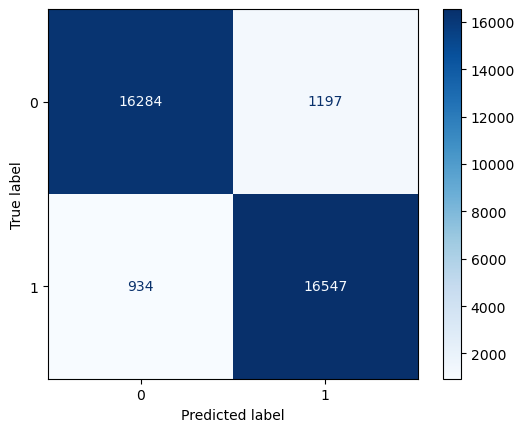

In [55]:
cm = confusion_matrix(y_test, smote_pred)

ConfusionMatrixDisplay(cm).plot(cmap="Blues")

Summary: 

In the fraud case recall for the positive (fraud) class is often the most important metric. Measures how many actual fraud cases are detected. Higher is generally better.

Also compare the precision: Measures how many predicted fraud cases are actually fraud. Prevents too many false alarms.

Accuracy: Usually not very informative for imbalanced data, so don't rely on it as the main comparison.

F1-score: Good overall metric because it balances precision and recall. Often the best single metric to compare sampling methods.